In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
df_c6a = pd.read_csv("data/Salmon_exec_times_c6a.csv")
df_c7a = pd.read_csv("data/Salmon_exec_times_c7a.csv")
df_c6a = df_c6a.groupby(["srr_id", "srr_size_MiB", "ebs_throughput", "ebs_iops","n_threads", "instance_type"]).mean().reset_index()
df_c7a = df_c7a.groupby(["srr_id", "srr_size_MiB", "ebs_throughput", "ebs_iops","n_threads", "instance_type"]).mean().reset_index()

In [5]:
#S(P) = T(1) / T(P)
#E(P) = S(P) / P
def calculate_speedup_efficiency(df):
    df["speedup"] = df.groupby('srr_id').apply(lambda group: group[group['n_threads'] == 1]['execution_time_seconds'].values[0] / group['execution_time_seconds']).reset_index().sort_values("level_1").reset_index()["execution_time_seconds"]
    df["efficiency"] = df["speedup"] / df["n_threads"] * 100
    return df

df_c6a = calculate_speedup_efficiency(df_c6a)
df_c7a = calculate_speedup_efficiency(df_c7a)

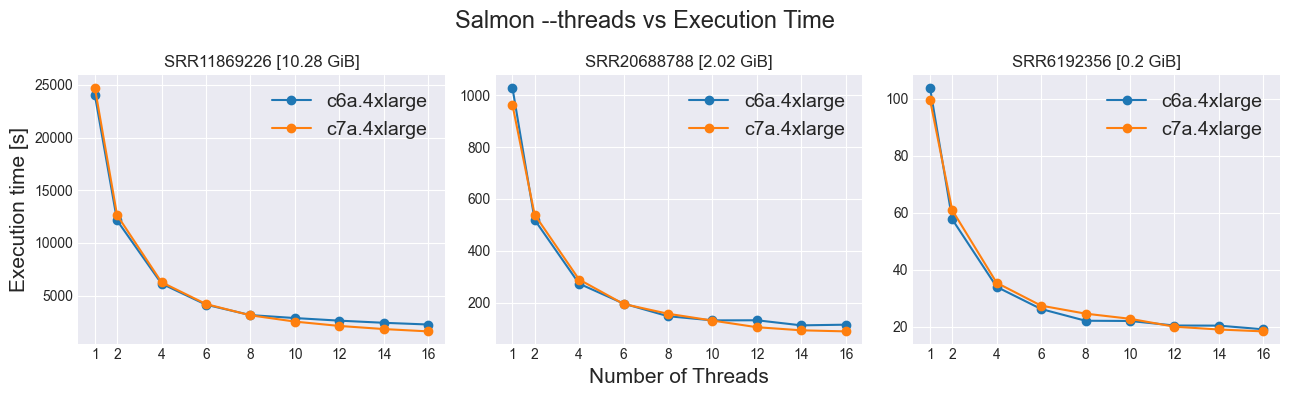

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4))

for i, (name, group) in enumerate(df_c6a.groupby("srr_id")):
    group.plot(x='n_threads', y='execution_time_seconds', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='',
               title=f"{name} [{round(group['srr_size_MiB'].iloc[0] / 1024, 2)} GiB]")
    axs[i].set_xticks(group["n_threads"])

for i, (name, group) in enumerate(df_c7a.groupby("srr_id")):
    group.plot(x='n_threads', y='execution_time_seconds', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='',
               title=f"{name} [{round(group['srr_size_MiB'].iloc[0] / 1024, 2)} GiB]")

    axs[i].legend(fontsize=14)

plt.suptitle("Salmon --threads vs Execution Time", fontsize=17)
axs[0].set_ylabel('Execution time [s]', fontsize=15)
axs[1].set_xlabel('Number of Threads', fontsize=15)
plt.tight_layout()
plt.savefig("plots/Salmon_scalability.pdf", format="pdf")

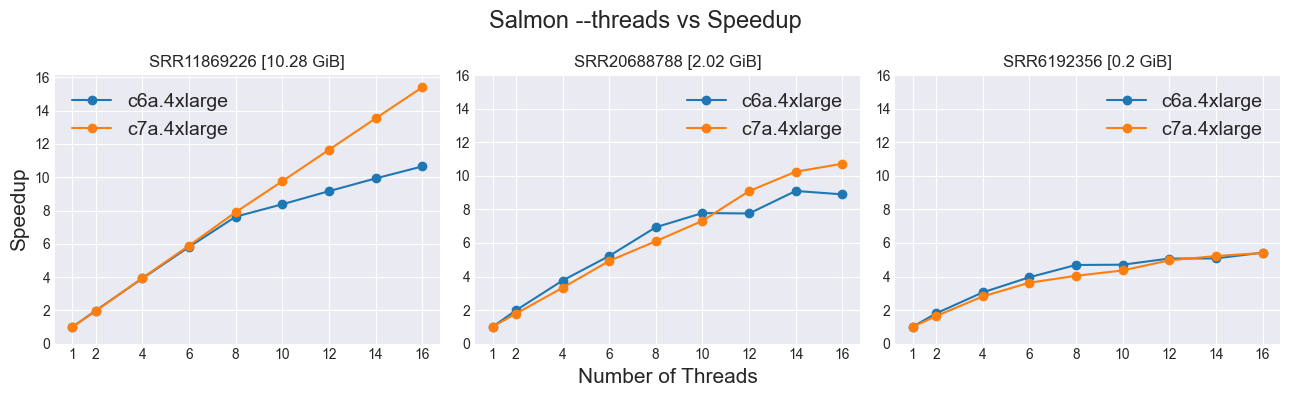

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4))

for i, (name, group) in enumerate(df_c6a.groupby("srr_id")):
    group.plot(x='n_threads', y='speedup', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='',
               title=f"{name} [{round(group['srr_size_MiB'].iloc[0] / 1024, 2)} GiB]").set_yticks(np.linspace(0, 16, 9))
    axs[i].set_xticks(group["n_threads"])

for i, (name, group) in enumerate(df_c7a.groupby("srr_id")):
    group.plot(x='n_threads', y='speedup', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='',
               title=f"{name} [{round(group['srr_size_MiB'].iloc[0] / 1024, 2)} GiB]").set_yticks(np.linspace(0, 16, 9))

    axs[i].legend(fontsize=14)

plt.suptitle("Salmon --threads vs Speedup", fontsize=17)
axs[0].set_ylabel('Speedup', fontsize=15)
axs[1].set_xlabel('Number of Threads', fontsize=15)
plt.tight_layout()
plt.savefig("plots/Salmon_speedup.pdf", format="pdf")

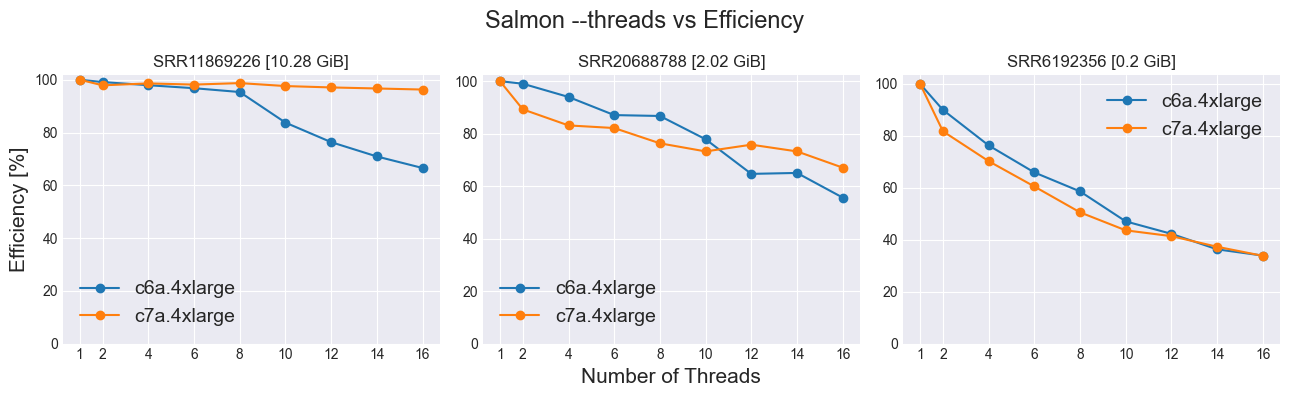

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4))

for i, (name, group) in enumerate(df_c6a.groupby("srr_id")):
    group.plot(x='n_threads', y='efficiency', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='',
               title=f"{name} [{round(group['srr_size_MiB'].iloc[0] / 1024, 2)} GiB]").set_yticks(np.linspace(0, 100, 6))
    axs[i].set_xticks(group["n_threads"])

for i, (name, group) in enumerate(df_c7a.groupby("srr_id")):
    group.plot(x='n_threads', y='efficiency', ax=axs[i], label=group["instance_type"].iloc[0], marker='o', linestyle='-', xlabel='', ylabel='',
               title=f"{name} [{round(group['srr_size_MiB'].iloc[0] / 1024, 2)} GiB]").set_yticks(np.linspace(0, 100, 6))

    axs[i].legend(fontsize=14)

plt.suptitle("Salmon --threads vs Efficiency", fontsize=17)
axs[0].set_ylabel('Efficiency [%]', fontsize=15)
axs[1].set_xlabel('Number of Threads', fontsize=15)
plt.tight_layout()
plt.savefig("plots/Salmon_efficiency.pdf", format="pdf")